# Script for Exercise 1 ("Modelling flexibility resources")

Script for Exercise 1 ("Modelling flexibility resources") in specialization 
course module "Flexibility in power grid operation and planning" at NTNU (TET4565/TET4575).
It involves a model of an Electric Water Heater (EWH) as a flexibility resource. 

In [9]:
# Define dependencies and EWH model function 

from math import exp
import matplotlib.pyplot as plt
import numpy as np


def make_load_profile_ewh(time_steps,P,T,S,T_a,C,R,T_min,T_max,t_act,S_act):
    """
    Generate load time series for electric water heater (EWH).
    
    Inputs:
        time_steps: Number of time steps (minutes) (int)
        P: Initial load demand of EWH in kW
        T: Initial temperature of EWH in degrees Celsius
        S: Initial EWH status (1 is heating, 0 is not)
        T_a: Ambient temperature in degrees Celsius
        C: Thermal capacitance in kWh/deg C
        R: Thermal resistance in (degrees Celsius)/kW
        T_min: Minimum allowed water temperature in degrees Celsius
        T_max: Maximum allowed water temperature in degrees Celsius        
        t_act: Time of flexibility activation (minutes)
        S_act: EWH thermostat status after activating flexibility; 1 turns all EWHs on; 
            0 turns all EWHs off
    
    Outputs:
        P_list: Load demand time series of EWH, list with one element per time step
        T_list: Temperature time series of EWH in degrees Celsius, 
            with one element per time step
        S_list: EWH status time series, list with one element per time step    
    """

    P_list = [P]
    T_list = [T]
    S_list = [S]

    for t in range(1,time_steps):        
        T_prev = T
        S_prev = S

        # Find the change of temperature for the next time step
        T = (T_prev - T_a - P_m * R * S_prev) * exp(-(1/60)/(C*R)) + T_a + P_m * R * S_prev 

        if (T <= T_min) & (S_prev == 0):
            # Turn EWH on if the temperature becomes too low
            S = 1
        elif (T > T_max) & (S_prev == 1):
            # Turn EWH off if the temperature becomes too high
            S = 0
        else:
            S = S_prev

        if (t == t_act) & (S_act is not None):
            # Activate flexibility
            S = S_act

        # The EWH operates at full power capacity if turned on
        P = S_prev * P_m

        P_list.append(P)
        T_list.append(T)
        S_list.append(S)

    return P_list, T_list, S_list

In [10]:
# Initialize Electric Water Heater model

#Rated power of EWH in kW
P_m = 2

#Ambient temperature in degrees Celsius
T_a = 24

#Minimum allowed water temperature in degrees Celsius
T_min = 70

#Maximum allowed water temperature in degrees Celsius
T_max = 75

#Thermal capacitance in kWh/deg C
C = 0.335

#Thermal resistance in deg C /kW
R = 600

# Initializing EWH temperature (only applicable if modelling a single EWH)
T = 73

# Initialize electric water heater(s) to be turned off
S = 0
P = 0

# Time of flexibility activation (minutes from start time); 
# set to None to disable flexibility activation
t_act = None

# EWH activation signal that sets the status of the EWHs after activating flexibility; 
# 1 turns all EWHs on; 0 turns all EWHs off; set to None to disable flexibility activation
S_act = None

# Number of time steps (minutes)
time_steps = 24*60

# Number of EWHs / hot water tanks to model
N_EWH = 1

if N_EWH == 1:
    # If modelling a single EWH, initialize temperature as specified above
    T_init = [T]
elif N_EWH > 1:
    # If modelling multiple EWHs, initialize with random temperature
    rng = np.random.default_rng(seed=42)
    T_init = rng.uniform(70,75,N_EWH)

# Initialize time series for aggregated load demand of all the EWHs 
P_list_all = np.zeros(time_steps)

# Initialize time series for aggregated baseline load demand of all the EWHs, 
# i.e., the expected load demand without flexibility activation
P_list_base_all = np.zeros(time_steps)

In [11]:
# Run Electric Water Heater model

# Loop over all the EWHs
for i_EWH in range(N_EWH):
    T = T_init[i_EWH]
    
    # Trick to initialize EWH status randomly approximately according to steady-state distribution
    if i_EWH > 0:        
        S = S_list[-1]
        P = P_list[-1]
    
    # Run EWH model without flexibility activation to obtain the baseline power consumption pattern
    P_list_base, T_list_base, _ = make_load_profile_ewh(time_steps,P,T,S,T_a,C,R,T_min,T_max,None,None)
    
    # Run EWH model with flexibility activation
    P_list, T_list, S_list = make_load_profile_ewh(time_steps,P,T,S,T_a,C,R,T_min,T_max,t_act,S_act)
    
    # Aggregate load time series
    P_list_all += np.array(P_list)
    P_list_base_all += np.array(P_list_base)

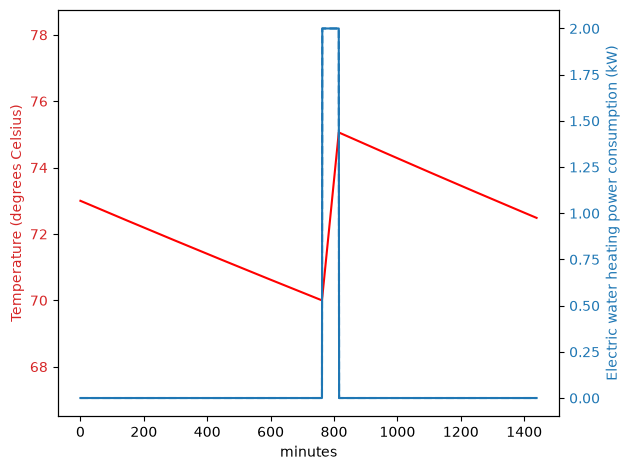

In [12]:
# Plot results for from Electric Water Heater model

if N_EWH == 1:
    # If running model for a single Electric Water Heater
    fig,ax1 = plt.subplots()
    if (t_act != None) & (S_act != None):
        h_T_base, = plt.plot(T_list_base, 'r--')
    h_T, = plt.plot(T_list, 'r')
    ax1.set_ylim(ymin = T_min * 0.95)
    ax1.set_ylim(ymax = T_max * 1.05)
    color1 = 'tab:red'
    ax1.set_xlabel('minutes')
    ax1.set_ylabel('Temperature (degrees Celsius)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    if (t_act != None) & (S_act != None):
        ax1.legend([h_T_base,h_T], ['without flex.','with flex.'], loc = 'upper left')

    ax2 = ax1.twinx()  # instantiate a minute Axes that shares the same x-axis
    color2 = 'tab:blue'
    ax2.set_ylabel('Electric water heating power consumption (kW)', color=color2)  # we already handled the x-label with ax1
    ax2.plot(P_list_base, color=color2, linestyle='dashed')
    ax2.plot(P_list, color=color2)    
    ax2.tick_params(axis='y', labelcolor=color2)
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()

elif N_EWH > 1:
    # If running model for multiple Electric Water Heaters
    fig,ax1 = plt.subplots()
    ax1.set_ylim(ymin = 0)
    ax1.set_ylim(ymax = P_list_base_all.max() * 1.05)
    color1 = 'tab:blue'
    ax1.set_ylabel('Aggregated electric water heating power consumption (kW)', color=color1)
    if (t_act != None) & (S_act != None):
        h_P_base, = ax1.plot(P_list_base_all, color=color1, linestyle='dashed')
    h_P, = ax1.plot(P_list_all, color=color1)
    if (t_act != None) & (S_act != None):
        ax1.legend([h_P_base,h_P], ['without flex.','with flex.'], loc = 'upper left')
    plt.show()